In [1]:
#Imports and other relevant stuff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
from scipy.spatial import Delaunay
import scipy.interpolate as interpolate
from mpl_toolkits.basemap import Basemap

In [2]:
#Importing the data into DataFrames
boredata= pd.read_csv("https://github.com/Matei-Stoica-Uni/Capstone-Case-Study---Australia/blob/main/Data/recharge-australia_data-bores.csv?raw=true")
griddata= pd.read_csv("https://github.com/Matei-Stoica-Uni/Capstone-Case-Study---Australia/blob/main/Data/recharge-australia_data-gridded.csv?raw=true")

In [3]:
set_of_test_points_lon = np.array(boredata['Longitude'])
set_of_test_points_lat = np.array(boredata['Latitude'])
set_of_test_points_recharge_rate = np.array(boredata['Recharge_rate'])
set_of_test_points = np.c_[set_of_test_points_lon, set_of_test_points_lat]

set_of_test_points_gridded_lon = np.array(griddata['Longitude'])
set_of_test_points_gridded_lat = np.array(griddata['Latitude'])

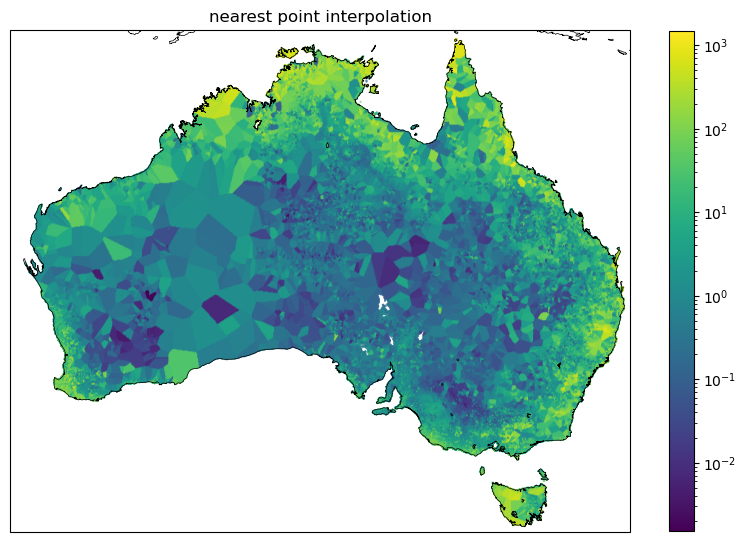

In [4]:
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
coast = Basemap(
    llcrnrlon=112, llcrnrlat=-44,
    urcrnrlon=154, urcrnrlat=-10,
    resolution='i')
coast.drawcoastlines(linewidth=.5)
#ax.add_feature(cfeature.LAND)
#ax.add_feature(cfeature.BORDERS)
#ax.add_feature(cfeature.COASTLINE)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
interp_nearest = interpolate.NearestNDInterpolator(set_of_test_points, set_of_test_points_recharge_rate)
cax = ax.scatter(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat, s=0.1, norm=colors.LogNorm(), c=interp_nearest(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat), cmap='viridis')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.title('nearest point interpolation')
plt.show()

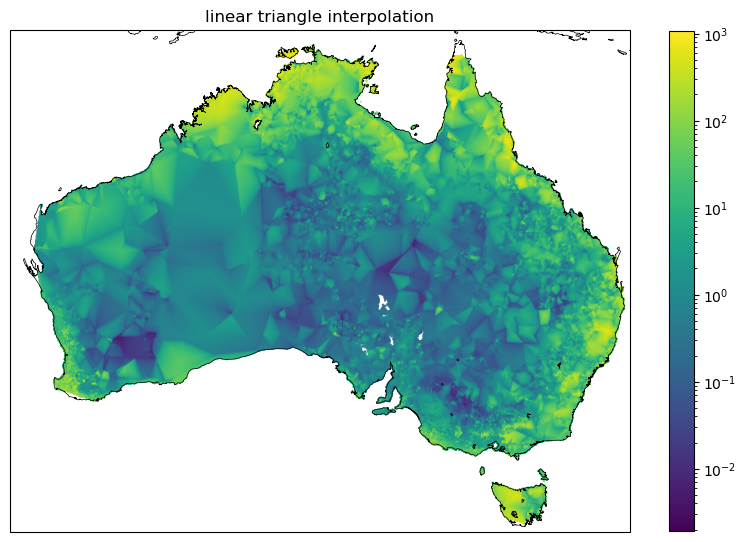

In [5]:
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
coast = Basemap(
    llcrnrlon=112, llcrnrlat=-44,
    urcrnrlon=154, urcrnrlat=-10,
    resolution='i')
coast.drawcoastlines(linewidth=.5)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
interp = interpolate.LinearNDInterpolator(set_of_test_points, set_of_test_points_recharge_rate)
cax = ax.scatter(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat, s=0.1, norm=colors.LogNorm(), c=interp(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat), cmap='viridis')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.title('linear triangle interpolation')
plt.show()

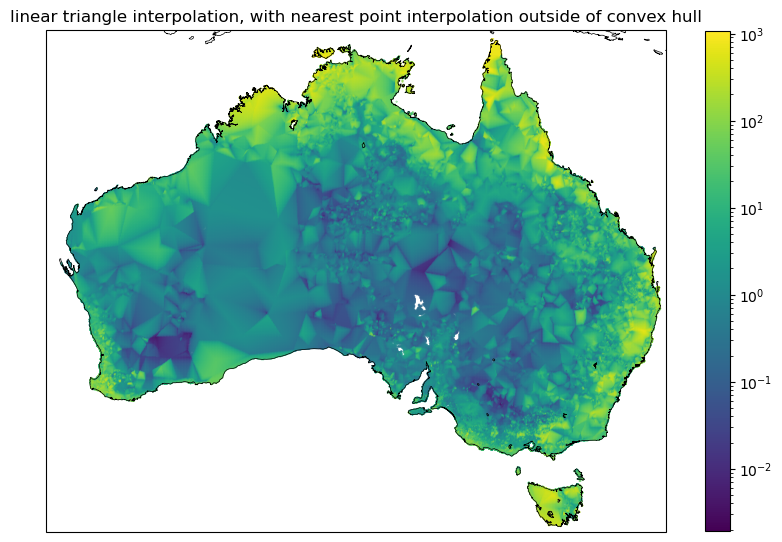

In [6]:
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
coast = Basemap(
    llcrnrlon=112, llcrnrlat=-44,
    urcrnrlon=154, urcrnrlat=-10,
    resolution='i')
coast.drawcoastlines(linewidth=.5)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
interp = interpolate.LinearNDInterpolator(set_of_test_points, set_of_test_points_recharge_rate, fill_value=99999999)
interp_values = []
for i in range(len(set_of_test_points_gridded_lon)):
    if interp(set_of_test_points_gridded_lon[i], set_of_test_points_gridded_lat[i]) == 99999999:
        interp_values.append(interp_nearest(set_of_test_points_gridded_lon[i], set_of_test_points_gridded_lat[i]))
        #print(f'fill value at {i}')
    else:
        interp_values.append(interp(set_of_test_points_gridded_lon[i], set_of_test_points_gridded_lat[i]))
cax = ax.scatter(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat, s=0.1, norm=colors.LogNorm(), c=interp_values, cmap='viridis')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.title('linear triangle interpolation, with nearest point interpolation outside of convex hull')
plt.show()

[[36611 95403 33458]
 [88560 75953 88564]
 [16970 17244 15718]
 ...
 [31679 31708 31681]
 [31665 31712 31662]
 [31662 31712 31658]]


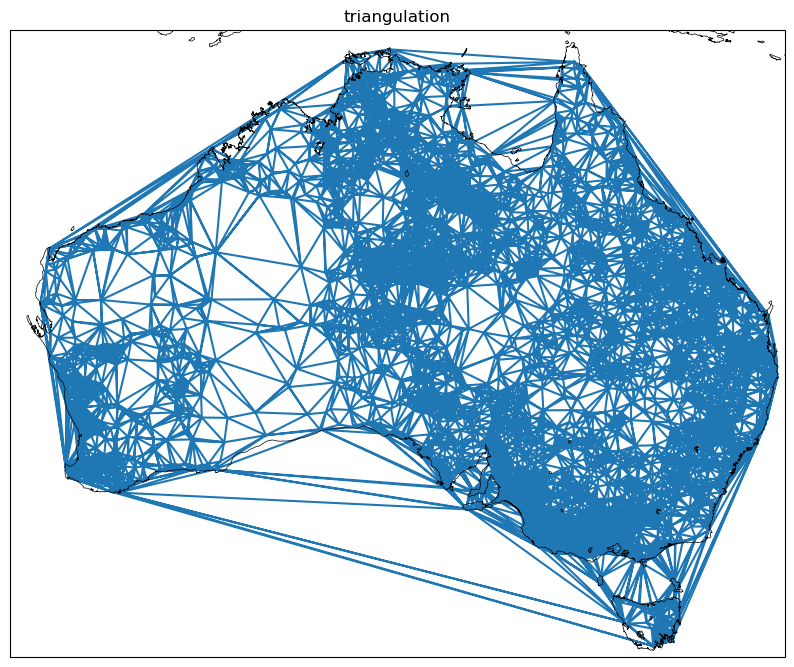

In [7]:
tri = Delaunay(set_of_test_points)
print(tri.simplices.copy())

plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
coast = Basemap(
    llcrnrlon=112, llcrnrlat=-44,
    urcrnrlon=154, urcrnrlat=-10,
    resolution='i')
coast.drawcoastlines(linewidth=.5)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
ax.triplot(set_of_test_points_lon,set_of_test_points_lat, tri.simplices.copy())
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.title('triangulation')
plt.show()

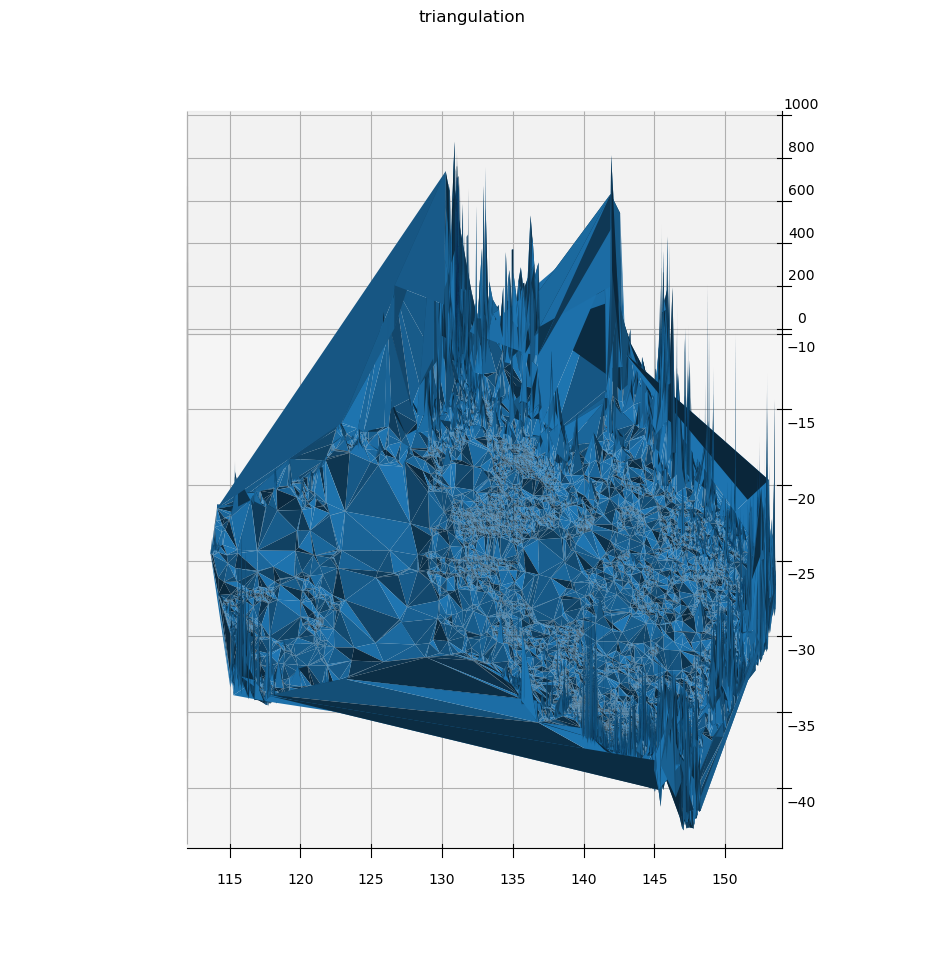

In [8]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
ax.set_proj_type('ortho') #sets 3d projection to be orthographic so there is no perspective distortion 
ax.plot_trisurf(set_of_test_points_lon, set_of_test_points_lat, np.clip(set_of_test_points_recharge_rate,a_min=0,a_max=999), triangles=tri.simplices.copy())
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
ax.view_init(elev=60, azim=-90, roll=0)
plt.title('triangulation')
plt.show()